## Separation

|Previous Notebook|Current Notebook|Next Notebook|
|:-:|:-:|:-:|
|-|<i>1.separate.ipynb</i>|[2.vr_blink_signals.ipynb](./2.vr_blink_signals.ipynb)|

The function of this notebook is to do the following:

1. Separate raw EEG data from processed EEG data calculated by **MM**.
2. Extract trials from calibration data
3. Produce new folders for each trial, each with their own set of files.

### Step 0: Imports & Global Variables

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from tqdm import tqdm
import importlib
from components import timestamps
from components import file_handling
from components import eeg_handling
importlib.reload(timestamps)
importlib.reload(file_handling)
importlib.reload(eeg_handling)

pd.set_option('display.max_colwidth', None)   # Show full cell contents
pd.set_option('display.max_columns', None)    # Show all columns
pd.set_option('display.width', None)          # Don't wrap lines
pd.set_option('display.float_format', '{:.0f}'.format)

## Step 1: Find all participant files

A simple walk to identify, based on `_ACTIVE_PARTICIPANTS`, which files are present for which participants.

In [2]:
_DATA_DIR = "data/"
_ACTIVE_PARTICIPANTS = [
    'P1',
    'PI2',
    'P2',
    'P3',
    'P4_Muse2',
    'P5'
]

p_dirs = [{'p':p, 'd':os.path.join(_DATA_DIR, p+'/')} for p in _ACTIVE_PARTICIPANTS]
participants = [{'p':p['p'], 'input_dir': p['d'], 'trials':[], 'files':file_handling.find_files(p['d'])} for p in p_dirs]

## Step 2: Filter Participants

For each participant in `participants`, we need to check the following:

1. They must not be empty
2. They must have the following files:
    - `calibration_1.csv` to `calibration_7.csv`
    - `eeg_rest.csv`
    - `eeg_vr.csv`
    - `pedestrians.csv`

Any participants who don't have the required files are bonkered out.

In [3]:
_EXPECTED_FILES = [
    'eeg_rest.csv',
    'eeg_vr.csv',
    'eye.csv',
    'pedestrians.csv',
    'calibration_1.csv',
    'calibration_2.csv',
    'calibration_3.csv',
    'calibration_4.csv',
    'calibration_5.csv',
    'calibration_6.csv',
    'calibration_7.csv'
]

def CheckParticipant(p, expected, check_log):
    # Must not be empty
    if len(p['files']) == 0:
        check_log.append((p['p'], "No files detected"))
        return False
    
    # Must have the following files
    for f in expected:
        if f not in p['files']: 
            check_log.append((p['p'], f"`{f}` does not exist"))
            return False
    
    # Return true otherwise
    return True

filter_log = []
participants = list(filter(lambda p: CheckParticipant(p, _EXPECTED_FILES, filter_log), participants))

display(Markdown("**Valid Participants**:"))
display(Markdown("".join([f"- {p['p']}\n" for p in participants])))
if len(filter_log) > 0:
    display(Markdown("**Filter Log**:"))
    display(Markdown("".join([f"- _{p[0]}_: p[1]" for p in filter_log])))

**Valid Participants**:

- P1
- PI2
- P2
- P3
- P4_Muse2
- P5


## Step 2: Generate output folders

Rather than mutate the original `./data` directory, we'll create a `./data2` directory where the new modified data is stored. Within this new directory, we want to generate a directory for each participant.

In [4]:
# Delete an existing `./data2` if it exists
file_handling.deletedirs('./data2')

# Iterate through each participant
for p in participants:
    # Extrapolate the output directory
    output_dir = f"./data2/{p['p']}/"
    
    # Create, delete existing if discovered
    file_handling.mkdirs(output_dir)

    # Save the results
    p['output_dir'] = output_dir

## Step 3: Extract REST-STAGE EEG

The first major thing we do is trying to read EEG data. We do this first with `eeg_rest.csv`.

There are two helper functions, `eeg_handling.read()` and `eeg_handling.separate()`, that we import from `./compnents/eeg_handling`. We use these functions to pre-process EEG data. We can use these functions elsewhere too.

In [5]:
_TRIAL_NAMES = [
    "Trial-ApproachAudio Start", 
    "Trial-BehindAudio Start", 
    "Trial-Behind Start", 
    "Trial-AlleyRunnerAudio Start", 
    "Trial-AlleyRunner Start", 
    "Trial-Approach Start"
]

for p in participants:
    # Read the `eeg_rest.csv` as a DataFrame
    eeg, blinks = eeg_handling.read(os.path.join(p['input_dir'], 'eeg_rest.csv'))
    raw, processed = eeg_handling.separate(eeg)

    # Have 3 versions: `raw`, `processed`, and `blinks`
    # Store the files inside of a `rest` directory
    output_dir = os.path.join(p['output_dir'], 'rest/')
    file_handling.mkdirs(output_dir)
    raw.to_csv(os.path.join(output_dir, 'raw.csv'), index=False)
    processed.to_csv(os.path.join(output_dir, 'processed.csv'), index=False)
    blinks.to_csv(os.path.join(output_dir, 'muse_blinks.csv'), index=False)
    

d:\Projects\eeg_blink_calibration\src\components\eeg_handling.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df.rename(columns=raw_colnames, inplace=True)
d:\Projects\eeg_blink_calibration\src\components\eeg_handling.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df.rename(columns=raw_colnames, inplace=True)
d:\Projects\eeg_blink_calibration\src\components\eeg_handling.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-c

## Step 4: Parse Trials

This is an intermediary step because we need to look at two things: 

- All the calibration files in `files`
- the `eye.csv`, which nests all the trial filenames and their starting timestamps

The issue is that, from the `eye.csv`, we need to extract all the trial start and end points. We **also** need to extract the start and end timestamps from the calibration files itself. Ideally, we would be able to produce a single DataFrame that contains all the the necessary data.

### 4a. Visually Validating Calibration Files Relative to Eye Data

Let's generate a visualization for each participant that showcases, relative to `eye.csv`, when each calibration file was generated.

In [6]:
def eye_calibration_timeline(_PID, _EYE_F, _CALIBRATION_FS):
    
    # Get the eye dataframe
    eye_df = pd.read_csv(_EYE_F)

    # --- Get overall time range ---
    start_time = eye_df["unix_ms"].min()
    end_time = eye_df["unix_ms"].max()

    # --- Collect first timestamps from small files ---
    markers = []
    for f in _CALIBRATION_FS:
        df = pd.read_csv(f)
        if "unix_ms" not in df.columns:
            continue  # skip if missing
        first_time = df["unix_ms"].iloc[0]
        markers.append((f"{os.path.basename(f)}\n{first_time}", first_time))

    # --- Plot ---
    plt.figure(figsize=(12, 4))
    plt.plot(eye_df["unix_ms"], [0]*len(eye_df), alpha=0.2, label="Eye dataset timeline")

    # Add vertical markers for each smaller file
    for name, t in markers:
        plt.axvline(x=t, color='red', linestyle='--', alpha=0.7)
        plt.text(t, 0.1, name, rotation=90, verticalalignment='bottom', fontsize=8)

    # Add a vertical marker for the start and ends too.
    plt.axvline(x=start_time, color='blue', linestyle='--', alpha=0.7)
    plt.text(start_time, 0.1, f"Eye Start\n{start_time}", rotation=90, verticalalignment='bottom', fontsize=7.5)

    # Render other stuff
    plt.xlim(start_time, end_time)
    plt.xlabel("Unix time (ms)")
    plt.yticks([])
    plt.title(f"Participant {_PID}: Timeline of Eye Data to Calibrations:")
    plt.legend()
    plt.tight_layout()
    plt.show()

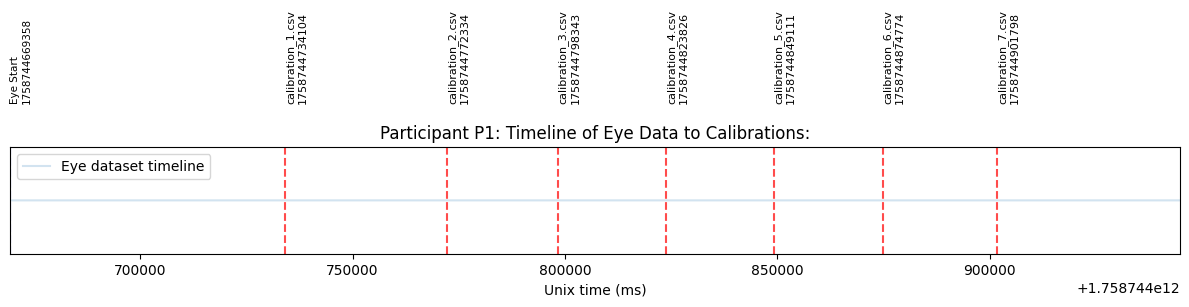

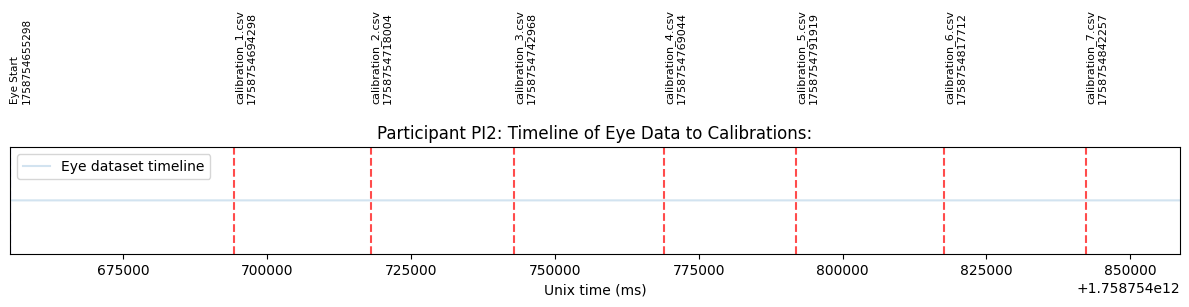

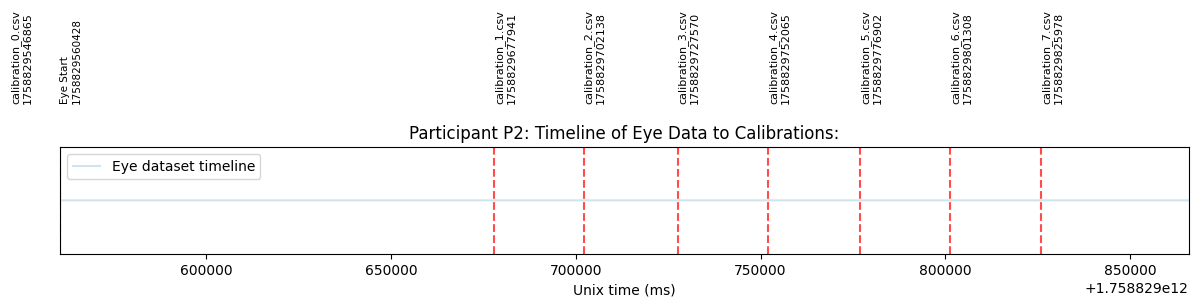

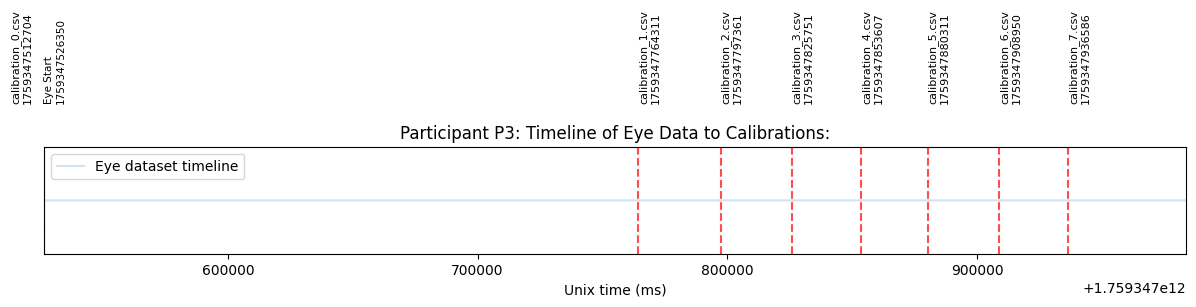

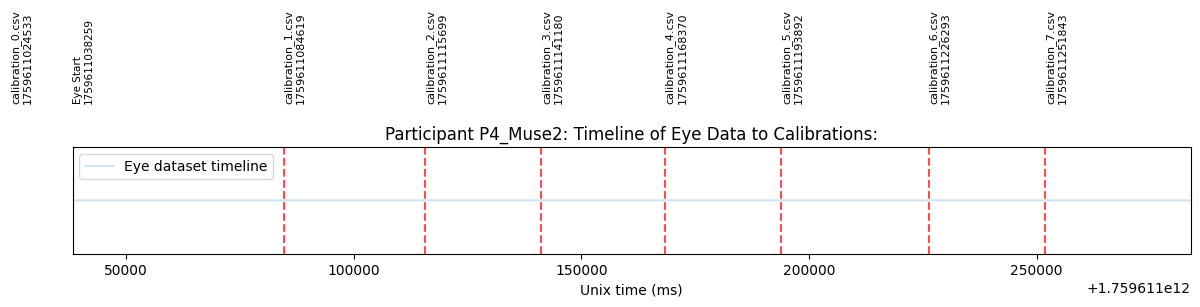

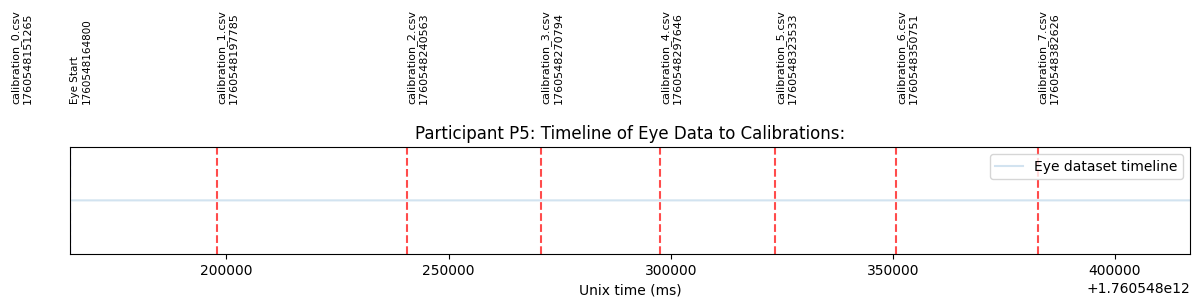

In [7]:
for p in participants:

    # Get all calibration files.
    calibration_files = [os.path.join(p['input_dir'], f) for f in p['files'] if 'calibration_' in f]

    # Render timeline between eye.csv and all calibration files
    eye_calibration_timeline(p['p'], os.path.join(p['input_dir'], 'eye.csv'), calibration_files)


### 4b. A note about calibration files

There are expected to be **6** trials. These _should_ range from `calibration_1.csv` to `calibration_6.csv`. The 7th calibration file, `calibration_7.csv`, is not an actual trial. It's the final eye calibration step that occurs AFTER the last trial. A majority of participants after PI1 and P1 have a `calibration_test.csv` or `calibration_0.csv` file. This occurs before even the eye tracking data starts recording; it is the first calibration cycle that runs prior to the acclimation phase. We generally try to ignore this one and anything after `calibration_7.csv`.

### 4c. Finalizing trial data, generating trial folders, & moving calibration files

This is the multi-tiered setup:

1. Extract trial names from `eye.csv`
2. Determine trial start and end times, with the help of `calibration_7.csv`
3. Generate folders for each trial
4. Saving cleaned calibration files to each of their respective trial folders
5. Saving a trial dataframe inside of the `trials/` directory of each participant.

In [8]:
_CALIBRATION_COLUMNS = [
    'unix_ms', 
    'frame', 
    'rel_timestamp',
    'event', 
    'overlap_counter'
]

def read_calibration_file(_F:str, correction:bool=True):
    # Read the file
    df = pd.read_csv(_F)

    # Correction, if necessary
    if correction: 
        df = df.iloc[:, :len(_CALIBRATION_COLUMNS)]
        df.columns = _CALIBRATION_COLUMNS

    # Return
    return df

In [9]:
_TRIAL_NAMES = [
    "Trial-ApproachAudio Start", 
    "Trial-BehindAudio Start", 
    "Trial-Behind Start", 
    "Trial-AlleyRunnerAudio Start", 
    "Trial-AlleyRunner Start", 
    "Trial-Approach Start"
]

for p in participants:
    
    # Load eye.csv
    eye_df = pd.read_csv(os.path.join(p['input_dir'], 'eye.csv'))

    # Extract only trial rows
    trials_df = eye_df[eye_df['event'].isin(_TRIAL_NAMES)]
    trials_df = trials_df[['event', 'unix_ms', 'frame']].rename(columns={'event':'trial_name', 'unix_ms':'start_unix_ms', 'frame':'start_frame'})
    trials_df = trials_df.sort_values('start_unix_ms')

    # Calculate ends of trials by looking at the next row.
    trials_df['end_unix_ms'] = trials_df['start_unix_ms'].shift(-1)
    trials_df['end_frame'] = trials_df['start_frame'].shift(-1)

    # To get the last entries of `end_unix_ms` and `end_frame`, we have to look at `calibration_7.csv`
    last_cal_df = read_calibration_file(os.path.join(p['input_dir'], 'calibration_7.csv'))
    last_cal_first = last_cal_df.iloc[0].to_dict()
    last_cal_start = last_cal_first['unix_ms']
    last_cal_frame = last_cal_first['frame']

    # then append it to our trials
    trials_df.at[trials_df.index[-1], 'end_unix_ms'] = last_cal_start
    trials_df.at[trials_df.index[-1], 'end_frame'] = last_cal_frame

    # Cleanup: 
    # 1. Create "trial #" column that numbers each trial, 
    # 2. Rename trials to remove extraneous info, and 
    # 3. Mark if a trial is one that involves audio or not
    trials_df['trial_id'] = range(1, len(trials_df) + 1)
    trials_df['trial_name'] = trials_df['trial_name'].apply(lambda x: (x.split(" ")[0]).split('-')[1])
    trials_df['trial_audio'] = trials_df['trial_name'].apply(lambda x: "Audio" in x)

    # Create a directory for each trial, save the calibration file associated with that trial, and save it inside of a subdirectory in each trial called `calibration/`
    for index, row in trials_df.iterrows():
        # Create the directory
        tdir = os.path.join(p['output_dir'], f"{row['trial_id']}/")
        file_handling.mkdirs(tdir)
        p['trials'].append(f"{row['trial_id']}")

        # Create a `calibration` subdirectory inside the trial directory
        cdir = os.path.join(tdir, 'calibration/')
        file_handling.mkdirs(cdir)

        # Find the calibration file associated with this trial. Skip if not found
        if f"calibration_{row['trial_id']}.csv" not in p['files']:
            print(f"Calibration file 'calibration_{row['trial_id']}.csv' not present in participant {p['p']}'s files! Exiting early.", file=sys.stderr)
            continue
        
        # Save calibration file (cleaned up one)
        cdf = read_calibration_file(os.path.join(p['input_dir'], f"calibration_{row['trial_id']}.csv"))
        cdf.to_csv(os.path.join(cdir, "calibration.csv"), index=False)        

    # Create a csv with the trial data.
    # We save the filename as "simulations.csv" instead, because these timestamps
    # are only captured during the simulation.
    trials_df.to_csv(os.path.join(p['output_dir'], 'trials.csv'), index=False)

## Step 5: Separate EEG, eye, and pedestrians data based on trial data

With the trial data saved to `trials/trials.csv` for each participant, we can begin to start parsing `eeg_vr.csv`, `eye.csv`, and `pedestrians.csv`. We need to be able to split the data between each trial, and then for each trial, split between calibration and actual data.

In [10]:
# Set up a progress bar for easy visual understanding of the progress of this step
pbar = tqdm(range(len(participants)), desc="Separating Participants...")
for i in pbar:
    # Get the participant from `i`
    p = participants[i]
    pbar.set_description(f"Processing Participant {p['p']}")

    # Read the `eeg_vr.csv`, `eye.csv`, and `pedestrians.csv`
    eeg, muse_blinks = eeg_handling.read(os.path.join(p['input_dir'], 'eeg_vr.csv'))
    raw, processed = eeg_handling.separate(eeg)
    eye = pd.read_csv(os.path.join(p['input_dir'], 'eye.csv'))
    positions = pd.read_csv(os.path.join(p['input_dir'], 'pedestrians.csv'))

    # Let's save these versions of the files inside of `trials`
    # Start saving our files appropriately. First, we save the processed versions of the trial data
    muse_blinks.to_csv(p['output_dir'] + 'muse_blinks.csv')
    raw.to_csv(p['output_dir'] + 'eeg_raw.csv')
    processed.to_csv(p['output_dir'] + 'eeg_processed.csv')
    eye.to_csv(p['output_dir'] + 'eye.csv')
    positions.to_csv(p['output_dir'] + 'positions.csv')

    # Read the trial data
    trials_df = pd.read_csv(os.path.join(p['output_dir'], 'trials.csv'))

    # Before we start iterating through the trials, let's save the timestamps of our calibrations for now. We'll merge this data into `trials_df`, and save a new version of it down the line
    cal_trial_ids = []
    cal_start_times = []
    cal_start_frames = []
    cal_end_times = []
    cal_end_frames = []

    # Iterate through each trial row
    for index, trial in trials_df.iterrows():
        # Get the start and end times of the trial
        trial_start_time = trial['start_unix_ms']
        trial_start_frame = trial['start_frame']
        trial_end_time = trial['end_unix_ms']
        trial_end_frame = trial['end_frame']
        trial_id = trial['trial_id']
        
        # Read the calibration data for the current trial, and grab the start/end times/frames
        cal_dir = os.path.join(p['output_dir'], f'{trial_id}/calibration/')
        cdf = pd.read_csv(cal_dir + 'calibration.csv')
        cal_start_end = cdf[cdf['event'].isin(['Start','End'])]
        cal_start_row = cal_start_end[cal_start_end['event'] == 'Start'].iloc[0]
        cal_end_row = cal_start_end[cal_start_end['event'] == 'End'].iloc[0]
        cal_start_time = cal_start_row['unix_ms']
        cal_start_frame = cal_start_row['frame']
        cal_end_time = cal_end_row['unix_ms']
        cal_end_frame = cal_end_row['frame']

        # Now, we need to extract the dataset subsets only relevant to this current trial
        # The only dataset that doesn't have unix milliseconds is `positions`

        # Firstly, the entire trial data from calibration start to simulation end
        trial_dfs = {
            'muse_blinks': muse_blinks[muse_blinks['unix_ms'].between(cal_start_time, trial_end_time)],
            'raw': raw[raw['unix_ms'].between(cal_start_time, trial_end_time)],
            'processed': processed[processed['unix_ms'].between(cal_start_time, trial_end_time)],
            'eye': eye[eye['unix_ms'].between(cal_start_time, trial_end_time)],
            'positions': positions[positions['frame'].between(cal_start_frame, trial_end_frame)]
        }

        # Secondly, only the data pertaining to calibration stages
        cal_dfs = {
            'muse_blinks': muse_blinks[muse_blinks['unix_ms'].between(cal_start_time, cal_end_time)],
            'raw': raw[raw['unix_ms'].between(cal_start_time, cal_end_time)],
            'processed': processed[processed['unix_ms'].between(cal_start_time, cal_end_time)],
            'eye': eye[eye['unix_ms'].between(cal_start_time, cal_end_time)],
            'positions': positions[positions['frame'].between(cal_start_frame, cal_end_frame)]
        }

        # Thirdly, only the data pertaining to simulation stages
        sim_dfs = {
            'muse_blinks': muse_blinks[muse_blinks['unix_ms'].between(trial_start_time, trial_end_time)],
            'raw': raw[raw['unix_ms'].between(trial_start_time, trial_end_time)],
            'processed': processed[processed['unix_ms'].between(trial_start_time, trial_end_time)],
            'eye': eye[eye['unix_ms'].between(trial_start_time, trial_end_time)],
            'positions': positions[positions['frame'].between(trial_start_frame, trial_end_frame)]
        }

        # Saving! 
        # Firstly, we start saving our calibration files, as we already have the calibration directory
        cal_dfs['muse_blinks'].to_csv(os.path.join(cal_dir,'muse_blinks.csv'), index=False)
        cal_dfs['raw'].to_csv(os.path.join(cal_dir,'eeg_raw.csv'), index=False)
        cal_dfs['processed'].to_csv(os.path.join(cal_dir,'eeg_processed.csv'), index=False)
        cal_dfs['eye'].to_csv(os.path.join(cal_dir,'eye.csv'), index=False)
        cal_dfs['positions'].to_csv(os.path.join(cal_dir,'positions.csv'), index=False)

        # Secondly, make a directory for the simulation and place our dataframes in there
        sim_dir = os.path.join(p['output_dir'], f'{trial_id}/simulation/')
        file_handling.mkdirs(sim_dir)
        sim_dfs['muse_blinks'].to_csv(os.path.join(sim_dir,'muse_blinks.csv'), index=False)
        sim_dfs['raw'].to_csv(os.path.join(sim_dir,'eeg_raw.csv'), index=False)
        sim_dfs['processed'].to_csv(os.path.join(sim_dir,'eeg_processed.csv'), index=False)
        sim_dfs['eye'].to_csv(os.path.join(sim_dir,'eye.csv'), index=False)
        sim_dfs['positions'].to_csv(os.path.join(sim_dir,'positions.csv'), index=False)

        # Lastly, we also make a directory for the combined data
        comb_dir = os.path.join(p['output_dir'], f'{trial_id}/combined/')
        file_handling.mkdirs(comb_dir)
        trial_dfs['muse_blinks'].to_csv(os.path.join(comb_dir,'muse_blinks.csv'), index=False)
        trial_dfs['raw'].to_csv(os.path.join(comb_dir,'eeg_raw.csv'), index=False)
        trial_dfs['processed'].to_csv(os.path.join(comb_dir,'eeg_processed.csv'), index=False)
        trial_dfs['eye'].to_csv(os.path.join(comb_dir,'eye.csv'), index=False)
        trial_dfs['positions'].to_csv(os.path.join(comb_dir,'positions.csv'), index=False)

        # Record our calibrations
        cal_trial_ids.append(trial_id)
        cal_start_times.append(cal_start_time)
        cal_start_frames.append(cal_start_frame)
        cal_end_times.append(cal_end_time)
        cal_end_frames.append(cal_end_frame)

    # Closing things out, let's make modifications to `trials.csv` by adding the calibration timings per trial row.
    cal_timings = pd.DataFrame({
        'trial_id': cal_trial_ids,
        'cal_start_unix_ms': cal_start_times,
        'cal_start_frame': cal_start_frames,
        'cal_end_unix_ms': cal_end_times,
        'cal_end_frame': cal_end_frames
    })
    _trials_df = pd.merge(
        trials_df,
        cal_timings,
        on='trial_id'
    )
    _trials_df = _trials_df.rename(columns={
        'start_unix_ms':'sim_start_unix_ms', 
        'start_frame': 'sim_start_frame',
        'end_unix_ms':'sim_end_unix_ms',
        'end_frame': 'sim_end_frame'
    })
    _trials_df['start_unix_ms'] = _trials_df['cal_start_unix_ms']
    _trials_df['start_frame'] = _trials_df['cal_start_frame']
    _trials_df['end_unix_ms'] = _trials_df['sim_end_unix_ms']
    _trials_df['end_frame'] = _trials_df['sim_end_frame']
    _trials_df = _trials_df[['trial_id', 'trial_name', 'start_unix_ms', 'start_frame', 'end_unix_ms', 'end_frame', 'cal_start_unix_ms', 'cal_start_frame', 'cal_end_unix_ms', 'cal_end_frame', 'sim_start_unix_ms', 'sim_start_frame', 'sim_end_unix_ms', 'sim_end_frame']]
    
    # save the combined version
    _trials_df.to_csv(os.path.join(p['output_dir'], 'trials.csv'), index=False)

# let the progress bar know we're done
pbar.set_description(f"All participants processed")

Processing Participant P1:   0%|          | 0/6 [00:00<?, ?it/s] d:\Projects\eeg_blink_calibration\src\components\eeg_handling.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df.rename(columns=raw_colnames, inplace=True)
Processing Participant PI2:  17%|█▋        | 1/6 [00:08<00:44,  8.85s/it]d:\Projects\eeg_blink_calibration\src\components\eeg_handling.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df.rename(columns=raw_colnames, inplace=True)
Processing Participant P2:  33%|███▎      | 2/6 [00:18<00:36,  9.19s/it] d:\Projects\eeg_blink_calibration\src\components\eeg_handling.py:56: SettingWithCopyW

## Step 6: Defining Blink Ranges in Calibration Data

At this point, we have **2** timestamps for each suspected blink during calibration stages: 1) the "overlap" timestamp when, during the calibration phase, the red dot overlaps the gray dot, and 2) the blink "detected" by the Muse device. We know, definitively, that there will always be **four** overlaps. It's variable whether a muse-detected blink occurs after that or WAYYY after that... or not at all. The best thing we can do is do the following:

1. Detect the closest muse blink that comes after the overlap - thus defining a "suspected blink range" that we can observe individually.
2. Identify the blinks that are VALID for analysis which will come in a later notebook at some point.

### 6a. Suspected Blink Range

Note that we add buffer time of 100ms before the overlap timestamp and 100ms after the muse-detected blink.

In [12]:
_PREPEND_BUFFER = 100
_APPEND_BUFFER = 100

# Set up a progress bar for easy visual understanding of the progress of this step
pbar = tqdm(range(len(participants)), desc="Separating Participants...")
for i in pbar:
    # Get the participant from `i`
    p = participants[i]
    pbar.set_description(f"Processing Participant {p['p']}")

    # Get trials
    pdir = f"./data2/{p['p']}/"
    trials = pd.read_csv(os.path.join(pdir, "trials.csv"))

    # iterate through each trial
    for _, trial in trials.iterrows():

        trial_id = trial['trial_id']
        tdir = os.path.join(pdir, f"{trial_id}/calibration/")
        
        # Read trial calibrations
        cal = pd.read_csv(os.path.join(tdir, 'calibration.csv'))
        cdf = cal[cal['event'] == 'Overlap']
        # raw eeg and muse-detected blinks.
        muse_blinks = pd.read_csv(os.path.join(tdir, 'muse_blinks.csv'))
        eeg = pd.read_csv(os.path.join(tdir, 'eeg_raw.csv'))
        # Ensure that we only consider blinks 5sec after the start of the calibration file
        eeg_first_timestamp = eeg['unix_ms'].iloc[0]
        eeg_last_timestamp = eeg['unix_ms'].iloc[-1]
        muse_blinks = muse_blinks[muse_blinks['unix_ms'].between(eeg_first_timestamp + 5000.0, eeg_last_timestamp - 500)]
        
        # Use asof merge with direction='forward'. This gets the 'next' timestamp in muse_blinks after each overlap
        muse_blinks = muse_blinks.rename(columns={'unix_ms':'blink_unix_ms'})
        ranges = pd.merge_asof(
            cdf, muse_blinks,
            left_on='unix_ms',
            right_on='blink_unix_ms',
            direction='forward'
        )
        ranges = ranges.drop(columns=['frame', 'rel_timestamp', 'event', 'TimeStamp', 'unix_sec', 'rel_sec', 'rel_ms'])
        ranges = ranges[['overlap_counter', 'unix_ms', 'blink_unix_ms']]
        ranges = ranges.rename(columns={'unix_ms':'overlap_unix_ms'})

        # Filter NaN rows or rows where the next overlap timestamp comes before the current blink timestamp
        filtered = ranges.dropna(subset=['blink_unix_ms'])
        next_overlap = filtered['overlap_unix_ms'].shift(-1)
        mask = (next_overlap >= filtered['blink_unix_ms']) | (next_overlap.isna())
        filtered = filtered[mask]

        # We modify the unix milliseconds to account for a 100ms window before the overlap starts and after the blink is the detected
        filtered['start_unix_ms'] = filtered['overlap_unix_ms'] - _PREPEND_BUFFER
        filtered['end_unix_ms'] = filtered['blink_unix_ms'] + _APPEND_BUFFER
        filtered['duration'] = filtered['end_unix_ms'] - filtered['start_unix_ms']

        # Let's save the file as `calibration_blinks.csv` inside the trial's calibration directoryt
        filtered.to_csv(os.path.join(tdir, 'blink_ranges.csv'), index=False)

Processing Participant P5: 100%|██████████| 6/6 [00:01<00:00,  4.08it/s]      


## What's to be expected from running this notebook?

At this point, if you were to run through all the code blocks in order, then you should expect the following result:

1. Within each participant's directory in `src/data` is a new `trials/` directory.
2. Inside the `trials/` directory, you should see the following:
    - Each trial, marked from `1` to `6`
    - `rest/` that represents the baseline EEG data collection prior to all trials
    - `calibrations.csv` and `simulations.csv` = store timestamps for all calibration and simulation phases across the entire timeline.
    - `eeg_processed.csv` and `eeg_raw.csv` = contain the separated EEG signal data from the Mind Monitor application. These only contain signals and do not contain any blink data.
    - `muse_blinks.csv` = extracted blink data recorded by Mind Monitor from the EEG data.
    - `eye.csv` and `positions.csv` = the eye tracking and positional data recorded across the entire participant timeline.
3. Inside of each trial directory, you should see 3 subdirectories: `calibration/`, `simulation/`, and `combined/`. These should make sense: `calibration/` contains all data pertaining only to the calibration phase; `simulation/` contains all data pertaining only to the simulation phase, and `combined/` is the combined data. Each of these directories has the following files:
    - `calibration_timings.csv` and `simulations.csv` = store timestamps for all calibration and simulation phases across the entire timeline.
    - `eeg_processed.csv` and `eeg_raw.csv` = contain the separated EEG signal data from the Mind Monitor application. These only contain signals and do not contain any blink data.
    - `muse_blinks.csv` = extracted blink data recorded by Mind Monitor from the EEG data.
    - `eye.csv` and `positions.csv` = the eye tracking and positional data recorded across the entire participant timeline.

## What's Next?

|Previous Notebook|Current Notebook|Next Notebook|
|:-:|:-:|:-:|
|-|<i>1.separate.ipynb</i>|[2.vr_blink_signals.ipynb](./2.vr_blink_signals.ipynb)|

The next notebook to run is [`2.vr_blink_signals.ipynb`](./2.vr_blink_signals.ipynb), which endeavors to describe how we can theoretically extract blink data from eye data.